1. Wczytywanie i przygotowanie danych...

2. Budowa i trening modelu LSTM...
Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 17s 146ms/step - loss: 0.0278 - val_loss: 0.0019
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - loss: 0.0050 - val_loss: 0.0017
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - loss: 0.0049 - val_loss: 0.0017
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 0.0045 - val_loss: 0.0030
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - loss: 0.0046 - val_loss: 0.0020
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - loss: 0.0037 - val_loss: 0.0013
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - loss: 0.0042 - val_loss: 0.0016
Epoch 8/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0041 - val_loss: 0.0014
Epoch 9/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 0.0038 - val_loss: 0.0021
Epoch 10/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - loss: 0.0038 - val_loss: 0.0014
Epoch 11/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 

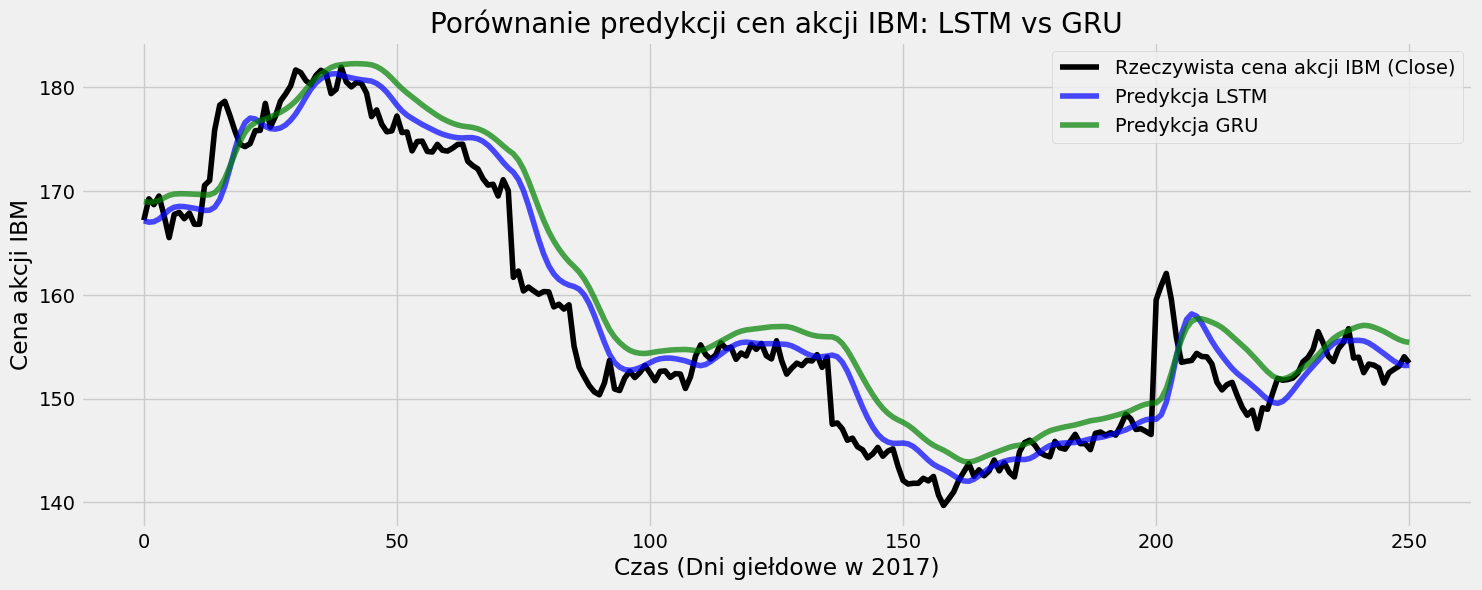

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Input
from keras.optimizers import Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error


def return_rmse(test, predicted, model_name):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print(f"[{model_name}] Błąd średniokwadratowy (RMSE): {rmse:.2f}")

def return_mae(test, predicted, model_name):
    mae = mean_absolute_error(test, predicted)
    mape = mean_absolute_percentage_error(test, predicted) * 100
    print(f"[{model_name}] Średni błąd bezwzględny (MAE): {mae:.2f}")
    print(f"[{model_name}] Błąd procentowy (MAPE): {mape:.2f}%\n")

print("1. Wczytywanie i przygotowanie danych...")

dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
training_set = dataset[:'2016'].iloc[:, 3:4].values # Indeks 3 to 'Close'
test_set = dataset['2017':].iloc[:, 3:4].values

sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)

X_train, y_train = [], []
for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n2. Budowa i trening modelu LSTM...")
model_lstm = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(units=50, return_sequences=True), Dropout(0.2),
    LSTM(units=50, return_sequences=True), Dropout(0.2),
    LSTM(units=50, return_sequences=True), Dropout(0.2),
    LSTM(units=50), Dropout(0.2),
    Dense(units=1)
])

model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop], verbose=1)

print("\n3. Budowa i trening modelu GRU...")
model_gru = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    GRU(units=50, return_sequences=True, activation='tanh'), Dropout(0.2),
    GRU(units=50, return_sequences=True, activation='tanh'), Dropout(0.2),
    GRU(units=50, return_sequences=True, activation='tanh'), Dropout(0.2),
    GRU(units=50, activation='tanh'), Dropout(0.2),
    Dense(units=1)
])
model_gru.compile(optimizer='adam', loss='mean_squared_error')
model_gru.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop], verbose=1)

print("\n4. Przygotowanie danych testowych...")
dataset_total = pd.concat((dataset['Close'][:'2016'], dataset['Close']['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

X_test = []
for i in range(60, len(inputs)):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

predicted_lstm = sc.inverse_transform(model_lstm.predict(X_test))
predicted_gru = sc.inverse_transform(model_gru.predict(X_test))

print("\n5. Ocena modeli (Zadanie F: RMSE < 2.0)...")
return_rmse(test_set, predicted_lstm, "LSTM")
return_mae(test_set, predicted_lstm, "LSTM")

return_rmse(test_set, predicted_gru, "GRU")
return_mae(test_set, predicted_gru, "GRU")

print("\n6. Wizualizacja porównawcza...")
plt.figure(figsize=(16, 6))
plt.plot(test_set, color='black', label='Rzeczywista cena akcji IBM (Close)')
plt.plot(predicted_lstm, color='blue', alpha=0.7, label='Predykcja LSTM')
plt.plot(predicted_gru, color='green', alpha=0.7, label='Predykcja GRU')
plt.title('Porównanie predykcji cen akcji IBM: LSTM vs GRU')
plt.xlabel('Czas (Dni giełdowe w 2017)')
plt.ylabel('Cena akcji IBM')
plt.legend()
plt.show()